# Wildfire → Solar · M0 input data · candidate 02 — FSim native FLP1-6 (USFS Probabilistic Wildfire Risk)

**Peril:** Wildfire · **Layer:** M0 (raw evidence) · method-neutral · assets: Hayhurst (TX, low-fire) +
Matrix (ID, high-fire) — same two as [`01_wrc_geoplatform`](01_wrc_geoplatform.ipynb).

The **second** M0 candidate. Where WRC 2.0 (candidate 01) **collapses** intensity into `CFL/FLEP4/FLEP8`,
this is the **native FSim** product — the **full 6-class flame-length histogram `FLP1-6`** (+ BP) at the
simulator's native **270 m**. Per [DD-W4](../../../docs/plans/wildfire/decisions.md) this is the **M1
severity spine**: the full histogram, single clean vintage, **no lossy reconstruction**.

This notebook (1) meets the histogram from scratch, (2) interprets every layer with its base, (3) verifies
`ΣFLP = 1`, and (4) runs the **cross-candidate comparison** — does `FLEP4 = ΣFLP₃₋₆` reproduce candidate
01's WRC FLEP? — which closes M0.

> Data dictionary (reference for every field): [`discussion/wildfire/02`](../../../docs/extra/discussion/wildfire/02_fsim_wrc_data_dictionary.md)
> · Plan: [`m0_input_data.md`](../../../docs/plans/wildfire/m0_input_data.md).

## 0 · Intent & scope

**Does:** fetch the native FSim BP + FLP1-6 histogram over each asset (270 m), interpret every layer, verify
`ΣFLP = 1`, boundary-zonal sample, and **reconcile against candidate 01 (WRC 2.0)**. **Does NOT:** compute
loss or build events — M1+. Public data, no auth, no secret ([DD-W3](../../../docs/plans/wildfire/decisions.md)).

## 1 · From scratch — the flame-length histogram (FLP1-6)

FSim simulates ≥20,000 fire seasons. For each 270 m pixel it records, **of all the simulated fires that
burned that pixel, the fraction whose flame length fell in each of six classes** (FIL1-6). That's the
**`FLP1-6` histogram** — six rasters that **sum to 1** (here served as integer **percent**, 0–100).

```text
  FLP histogram at one pixel (conditional on a fire):
    FIL1  <2 ft   ▓▓▓▓
    FIL2  2–4 ft  ▓▓▓▓▓▓▓▓▓▓▓▓
    FIL3  4–6 ft  ▓▓▓▓▓▓▓▓
    FIL4  6–8 ft  ▓▓▓
    FIL5  8–12 ft ▓
    FIL6  12+ ft  ·                     Σ = 100%
```

**Why this beats WRC's collapsed metrics for severity:** WRC gives only the *tails* `FLEP4 = P(>4 ft)` and
`FLEP8 = P(>8 ft)` — you can't recover the 6 bins from 2 numbers (under-determined → the lab's lossy
reconstruction). The native histogram **is** the severity distribution M3 wants. The relationship runs the
*other* way and is exact: `FLEP4 = ΣFLP₃₋₆`, `FLEP8 = ΣFLP₅₊₆` — which §10 verifies against candidate 01.

## 2 · The layers + the FIL class table (value + meaning + base)

| Layer | What it is | Units / base | **Conditioning** |
|---|---|---|---|
| **BP** | annual likelihood a pixel burns | probability 0–1 **/yr** (served ×10⁶ int32) | **annual (unconditional)** |
| **FLP1…FLP6** | fraction of burning fires in each flame-length class | **percent 0–100** (→ `/100`), **Σ=100%** | **conditional on fire** |

**FIL class table** (verified, data dictionary §3): half-open ft intervals; kW/m via Byram `FL_m=0.0775·I^0.46`
(approx). `FLEP4` break = 4 ft (hand-crew control limit); `FLEP8` break = 8 ft (equipment ceiling).

| Class | flame length | ≈ kW/m | midpoint ft (for mean) |
|---|---|---|---|
| FIL1 | <2 ft | <~50 | 1 |
| FIL2 | 2–4 ft | ~50–220 | 3 |
| FIL3 | 4–6 ft | ~220–520 | 5 |
| FIL4 | 6–8 ft | ~520–960 | 7 |
| FIL5 | 8–12 ft | ~960–2400 | 10 |
| FIL6 | 12+ ft | >~2400 | 15 |

In [1]:
from __future__ import annotations
import json, math, time
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import rasterio
import rasterio.features
from rasterio.enums import Resampling
from rasterio.transform import from_bounds as transform_from_bounds
from pyproj import Transformer
from shapely import wkb
import geopandas as gpd
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 110})
UA = {"User-Agent": "Mozilla/5.0"}   # geoplatform ImageServers 403 a default UA


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root not found")


ROOT = _repo_root()
DATA_DIR = ROOT / "data" / "wildfire"
RAW_BASE = DATA_DIR / "raw"
DATA_DIR.mkdir(parents=True, exist_ok=True)

ASSETS = [
    {"slug": "hayhurst_texas_solar", "name": "Hayhurst Texas Solar", "eia": 66880, "role": "baseline (low-fire)",
     "state": "TX", "county": "Culberson", "lat": 31.815992, "lon": -104.0853, "ac_mw": 24.8, "dc_mw": 31.31},
    {"slug": "matrix_pleasant_valley", "name": "Matrix Pleasant Valley", "eia": 67211, "role": "proving (high-fire)",
     "state": "ID", "county": "Ada", "lat": 43.301347, "lon": -115.998727, "ac_mw": 200.0, "dc_mw": None},
]
for a in ASSETS:
    a["dc_mw"] = a["dc_mw"] or round(a["ac_mw"] * 1.3, 1)
    a["footprint_r_m"] = round(69.0 * math.sqrt(a["dc_mw"]), 0)

# Real site boundaries (same source as 01): OSM/EIA plant polygons; circle fallback.
BND_PATH = ROOT / "renewablesinfo_org" / "data" / "dimensions" / "boundary" / "powerplants_enriched_v2.parquet"
_bnd = pd.read_parquet(BND_PATH, columns=["eia_id", "geometry"]) if BND_PATH.exists() else None
for a in ASSETS:
    sub = _bnd[_bnd["eia_id"] == str(a["eia"])] if _bnd is not None else []
    a["boundary"] = wkb.loads(sub.iloc[0]["geometry"]) if len(sub) else None
    if a["boundary"] is not None:
        km2 = float(gpd.GeoSeries([a["boundary"]], crs=4326).to_crs(5070).area.iloc[0]) / 1e6
        a["footprint"] = f"boundary polygon ({a['boundary'].geom_type}, {km2:.3f} km²)"
    else:
        a["footprint"] = f"capacity-radius circle (r≈{a['footprint_r_m']:.0f} m)"
    print(f"{a['name']:24s} ({a['role']}) → footprint: {a['footprint']}")

Hayhurst Texas Solar     (baseline (low-fire)) → footprint: capacity-radius circle (r≈386 m)
Matrix Pleasant Valley   (proving (high-fire)) → footprint: boundary polygon (MultiPolygon, 5.007 km²)


## 3 · Source & provenance

- **Product:** USFS **Probabilistic Wildfire Risk** (FSim) — the native simulator output; archive
  **`RDS-2016-0034-3`** (FSim 3rd Edition, Dillon et al. 2023, **LANDFIRE 2020**). Served via the same
  **geoplatform.gov** ImageServers as WRC. **Public / CC BY 4.0, no auth.**
  *(The `apps.fs.usda.gov` FSim ImageServers 403 programmatic access; geoplatform mirrors the same product.)*
- **Single clean vintage** (unlike WRC's BP-vs-intensity split): BP **and** the FLP histogram are the *same*
  270 m FSim product.
- **Scales (verified):** **FLP `/100`** (int8 percent → fraction, Σ=1); **BP `/1e6`** (int32 → annual prob).
  Non-burnable pixels = 0 across all FLP. Native **270 m** (so an asset smaller than ~270 m spans ≲1 pixel —
  a resolution caveat, esp. for tiny Hayhurst).
- Raw GeoTIFFs cached under `data/wildfire/raw/<slug>/fsim_*.tif`.

In [2]:
H = "https://imagery.geoplatform.gov/iipp/rest/services/Fire_Aviation"
FSIM = {**{f"FLP{i}": (f"{H}/USFS_EDW_RMRS_ProbabilisticWildfireRisk_FLP{i}/ImageServer", 1/100) for i in range(1, 7)},
        "BP": (f"{H}/USFS_EDW_RMRS_ProbabilisticWildfireRiskBurnProbability/ImageServer", 1/1e6)}
FIL_FT = ["<2", "2–4", "4–6", "6–8", "8–12", "12+"]
FIL_MID_FT = np.array([1.0, 3.0, 5.0, 7.0, 10.0, 15.0])
TARGET_M = 270.0                       # native FSim resolution — don't over-request
HALF_DEG = 0.20
_to3857 = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)


def asset_box(a):
    b = dict(lon_lo=a["lon"]-HALF_DEG, lon_hi=a["lon"]+HALF_DEG, lat_lo=a["lat"]-HALF_DEG, lat_hi=a["lat"]+HALF_DEG)
    xmin, ymin = _to3857.transform(b["lon_lo"], b["lat_lo"]); xmax, ymax = _to3857.transform(b["lon_hi"], b["lat_hi"])
    W = min(2048, max(64, round((xmax-xmin)/TARGET_M))); Hh = min(2048, max(64, round((ymax-ymin)/TARGET_M)))
    return b, (xmin, ymin, xmax, ymax), (W, Hh)


def fetch_fsim(a, layer, merc, size_xy) -> Path:
    out = RAW_BASE / a["slug"] / f"fsim_{layer}.tif"
    out.parent.mkdir(parents=True, exist_ok=True)
    if out.exists():
        return out
    xmin, ymin, xmax, ymax = merc
    params = {"bbox": f"{xmin},{ymin},{xmax},{ymax}", "bboxSR": "3857", "size": f"{size_xy[0]},{size_xy[1]}",
              "imageSR": "4326", "format": "tiff", "f": "image"}   # native pixelType (S8/S32)
    r = requests.get(f"{FSIM[layer][0]}/exportImage", params=params, headers=UA, timeout=120); r.raise_for_status()
    if r.content[:4] not in (b"\x49\x49\x2a\x00", b"\x4d\x4d\x00\x2a"):
        raise RuntimeError(f"{a['slug']}/{layer}: not a TIFF: {r.content[:200]!r}")
    out.write_bytes(r.content); time.sleep(0.4)
    return out


def read_raster(path, out_hw=None):
    with rasterio.open(path) as ds:
        native = (ds.height, ds.width)
        raw = (ds.read(1) if (out_hw is None or native == out_hw)
               else ds.read(1, out_shape=out_hw, resampling=Resampling.nearest)).astype("float64")
        prof = {"shape": raw.shape, "res_deg": (abs(ds.transform.a), abs(ds.transform.e))}
    return raw, prof


def load_asset(a):
    b, merc, (W, Hh) = asset_box(a)
    raw_bp, prof = read_raster(fetch_fsim(a, "BP", merc, (W, Hh)))
    ref = prof["shape"]
    bp = np.where(raw_bp < 0, np.nan, raw_bp) * FSIM["BP"][1]
    flp_raw = {}
    for i in range(1, 7):
        r, _ = read_raster(fetch_fsim(a, f"FLP{i}", merc, (W, Hh)), out_hw=ref)
        flp_raw[i] = np.where(r < 0, np.nan, r)            # int8 percent; non-burnable = 0
    flp_sum_raw = np.nansum(np.stack([flp_raw[i] for i in range(1, 7)]), axis=0)
    burnable = flp_sum_raw > 0
    flp = {i: flp_raw[i] / 100.0 for i in range(1, 7)}      # → fraction
    res_m = prof["res_deg"][0] * 111_320 * math.cos(math.radians(a["lat"]))
    return {"box": b, "ref_hw": ref, "res_m": res_m, "bp": bp, "flp": flp,
            "flp_sum_raw": flp_sum_raw, "burnable": burnable}

## 4 · Fetch + load both assets (BP + FLP1-6; cached)

In [3]:
DATA = {}
for a in ASSETS:
    print(f"loading {a['slug']} …", end="")
    DATA[a["slug"]] = load_asset(a)
    d = DATA[a["slug"]]
    print(f" grid {d['ref_hw']} ≈{d['res_m']:.0f} m/px · burnable {100*d['burnable'].mean():.0f}%")
print("done. raw GeoTIFFs cached under data/wildfire/raw/<slug>/fsim_*.tif")

loading hayhurst_texas_solar …

 grid (194, 165) ≈229 m/px · burnable 91%
loading matrix_pleasant_valley …

 grid (227, 165) ≈196 m/px · burnable 92%
done. raw GeoTIFFs cached under data/wildfire/raw/<slug>/fsim_*.tif


## 5 · Decode + verify ΣFLP = 1 (the histogram is a real distribution)

Over burnable pixels the six FLP must sum to 100% (→ 1.0). We check it explicitly — the basics-spot-on guard
that we're reading the histogram correctly before any severity use.

In [4]:
for a in ASSETS:
    d = DATA[a["slug"]]; bn = d["burnable"]
    s = d["flp_sum_raw"][bn]
    print(f"{a['name']:24s}: burnable {100*bn.mean():4.0f}% · ΣFLP(raw) over burnable mean={s.mean():.1f} "
          f"(expect ~100) p5={np.percentile(s,5):.0f} p95={np.percentile(s,95):.0f} · "
          f"BP max={np.nanmax(d['bp']):.4f}")
print("→ ΣFLP ≈ 100% confirms the 6 classes are a proper conditional distribution; /100 gives fractions.")

Hayhurst Texas Solar    : burnable   91% · ΣFLP(raw) over burnable mean=100.1 (expect ~100) p5=99 p95=101 · BP max=0.0027
Matrix Pleasant Valley  : burnable   92% · ΣFLP(raw) over burnable mean=99.9 (expect ~100) p5=99 p95=101 · BP max=0.0548
→ ΣFLP ≈ 100% confirms the 6 classes are a proper conditional distribution; /100 gives fractions.


## 6 · Field / grid dictionary — complete pass (per asset)

In [5]:
for a in ASSETS:
    d = DATA[a["slug"]]; bn = d["burnable"]
    rows = [{"layer": "BP", "meaning": "annual P(burn)", "unit/base": "prob 0–1 /yr", "conditioning": "annual",
             "obs_mean": round(float(np.nanmean(d["bp"])), 5), "obs_max": round(float(np.nanmax(d["bp"])), 5)}]
    for i in range(1, 7):
        v = d["flp"][i][bn]
        rows.append({"layer": f"FLP{i} ({FIL_FT[i-1]} ft)", "meaning": f"P(FIL{i} | fire)", "unit/base": "fraction (Σ=1)",
                     "conditioning": "conditional on fire", "obs_mean": round(float(np.nanmean(v)), 3),
                     "obs_max": round(float(np.nanmax(v)), 3)})
    print(f"\n=== {a['name']} ({a['role']}) — FSim field dictionary (FLP over burnable footprint region) ===")
    with pd.option_context("display.max_colwidth", 40, "display.width", 200):
        print(pd.DataFrame(rows).set_index("layer").to_string())
print(f"\nGrid: EPSG:4326 · native 270 m · FLP int8 percent (/100), BP int32 (/1e6) · non-burnable = 0 (Σ=0).")


=== Hayhurst Texas Solar (baseline (low-fire)) — FSim field dictionary (FLP over burnable footprint region) ===
                       meaning       unit/base         conditioning  obs_mean  obs_max
layer                                                                                 
BP              annual P(burn)    prob 0–1 /yr               annual   0.00037   0.0027
FLP1 (<2 ft)    P(FIL1 | fire)  fraction (Σ=1)  conditional on fire   0.42200   1.0000
FLP2 (2–4 ft)   P(FIL2 | fire)  fraction (Σ=1)  conditional on fire   0.33400   1.0000
FLP3 (4–6 ft)   P(FIL3 | fire)  fraction (Σ=1)  conditional on fire   0.16700   1.0000
FLP4 (6–8 ft)   P(FIL4 | fire)  fraction (Σ=1)  conditional on fire   0.05800   1.0000
FLP5 (8–12 ft)  P(FIL5 | fire)  fraction (Σ=1)  conditional on fire   0.01700   1.0000
FLP6 (12+ ft)   P(FIL6 | fire)  fraction (Σ=1)  conditional on fire   0.00200   1.0000

=== Matrix Pleasant Valley (proving (high-fire)) — FSim field dictionary (FLP over burnable footprint r

## 7 · Boundary-zonal footprint + the FLP histogram at each site

Footprint = real boundary polygon (Matrix) / capacity-radius circle (Hayhurst). We summarize, over the
footprint's **burnable** pixels: BP, the mean FLP per class (the site's flame-length histogram), the
**mean flame length** (Σ FLPᵢ·midpointᵢ), and the implied **FLEP4 = ΣFLP₃₋₆**, **FLEP8 = ΣFLP₅₊₆**.

In [6]:
def footprint_mask(a, d):
    b, (r, c) = d["box"], d["ref_hw"]
    if a.get("boundary") is not None:
        tr = transform_from_bounds(b["lon_lo"], b["lat_lo"], b["lon_hi"], b["lat_hi"], c, r)
        m = rasterio.features.rasterize([(a["boundary"], 1)], out_shape=(r, c), transform=tr,
                                        all_touched=True, dtype="uint8").astype(bool)
        if m.any():
            return m
    lons = np.linspace(b["lon_lo"], b["lon_hi"], c); lats = np.linspace(b["lat_hi"], b["lat_lo"], r)
    LON, LAT = np.meshgrid(lons, lats); R = 6_371_000.0
    hav = np.sin(np.radians(LAT-a["lat"])/2)**2 + math.cos(math.radians(a["lat"]))*np.cos(np.radians(LAT))*np.sin(np.radians(LON-a["lon"])/2)**2
    return (2*R*np.arcsin(np.sqrt(hav))) <= a["footprint_r_m"]


FZ = {}
for a in ASSETS:
    d = DATA[a["slug"]]
    fp = footprint_mask(a, d); fb = fp & d["burnable"]
    n_fp, n_burn = int(fp.sum()), int(fb.sum())
    bp_fp = float(np.nanmean(d["bp"][fp])) if fp.any() else np.nan
    if n_burn:
        flp_mean = np.array([float(np.nanmean(d["flp"][i][fb])) for i in range(1, 7)])
        flp_mean = flp_mean / flp_mean.sum()                      # renormalize over burnable footprint
    else:
        flp_mean = np.full(6, np.nan)
    mean_fl = float(np.dot(flp_mean, FIL_MID_FT)) if n_burn else np.nan
    flep4 = float(flp_mean[2:].sum()) if n_burn else np.nan
    flep8 = float(flp_mean[4:].sum()) if n_burn else np.nan
    FZ[a["slug"]] = {"bp": bp_fp, "flp_mean": flp_mean, "mean_fl_ft": mean_fl, "flep4": flep4, "flep8": flep8,
                     "n_footprint_px": n_fp, "n_burnable_px": n_burn}
    print(f"\n{a['name']} ({a['role']}) — footprint {a['footprint']}")
    print(f"  footprint pixels: {n_fp} (270 m)  ·  burnable: {n_burn}  ·  BP(mean)={bp_fp:.4f}")
    print(f"  FLP histogram (%): " + "  ".join(f"{FIL_FT[i]}:{100*flp_mean[i]:.0f}" for i in range(6)))
    print(f"  mean flame length ≈ {mean_fl:.1f} ft  ·  implied FLEP4={flep4:.3f}  FLEP8={flep8:.3f}")


Hayhurst Texas Solar (baseline (low-fire)) — footprint capacity-radius circle (r≈386 m)
  footprint pixels: 8 (270 m)  ·  burnable: 8  ·  BP(mean)=0.0004
  FLP histogram (%): <2:53  2–4:37  4–6:10  6–8:0  8–12:0  12+:0
  mean flame length ≈ 2.2 ft  ·  implied FLEP4=0.100  FLEP8=0.001

Matrix Pleasant Valley (proving (high-fire)) — footprint boundary polygon (MultiPolygon, 5.007 km²)
  footprint pixels: 184 (270 m)  ·  burnable: 170  ·  BP(mean)=0.0431
  FLP histogram (%): <2:0  2–4:34  4–6:46  6–8:17  8–12:4  12+:0
  mean flame length ≈ 4.9 ft  ·  implied FLEP4=0.662  FLEP8=0.040


## 8 · Maps (site-scale) + the per-site flame-length histogram

All site-scale (a few km), boundary overlaid — like `01`. Panels: BP, **mean flame length** (Σ FLPᵢ·midᵢ),
and the **dominant FIL class** (argmax) — plus the footprint FLP histogram bar.

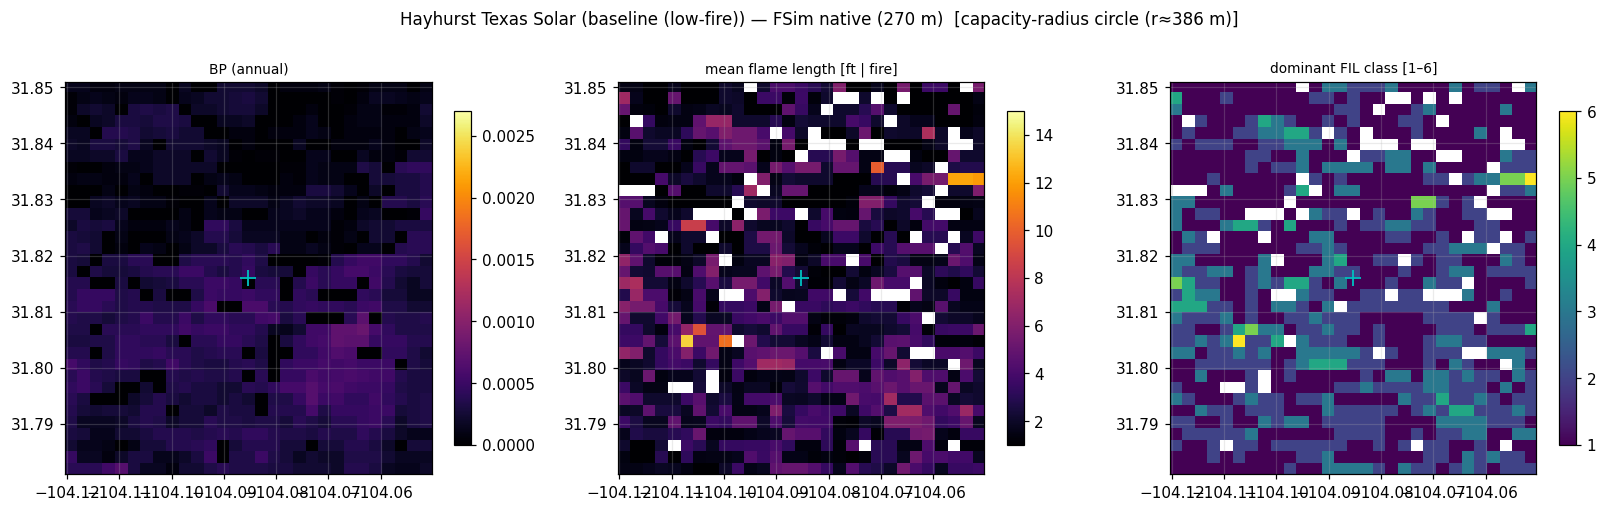

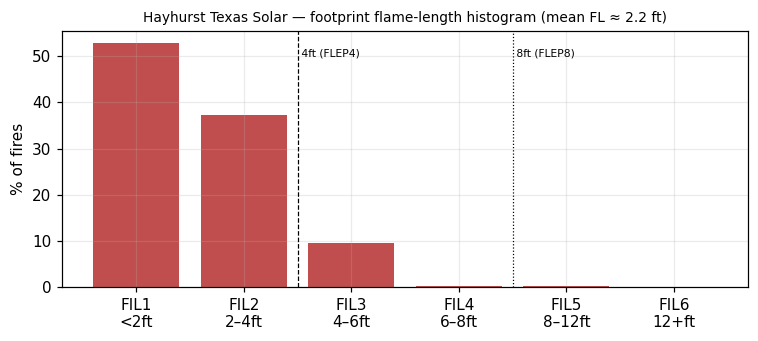

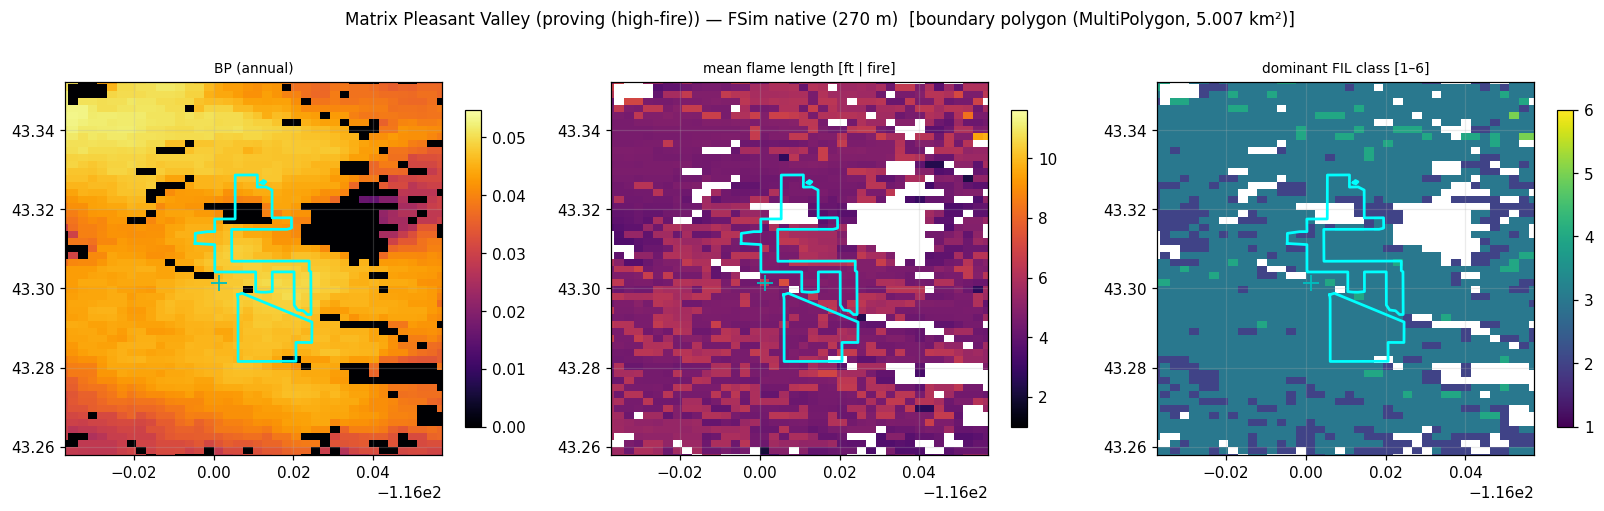

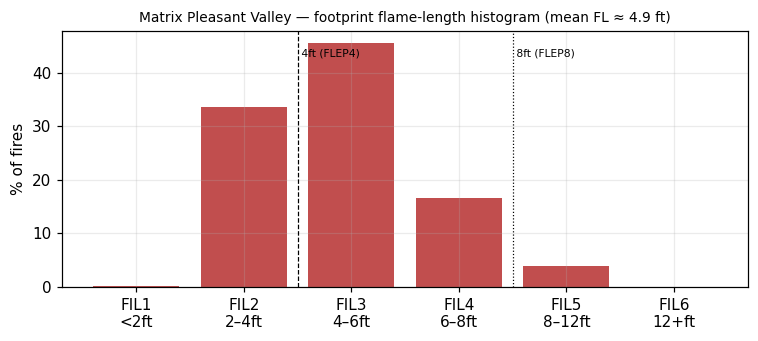

Takeaway: Matrix's histogram peaks at FIL2–3 (2–6 ft) with a real >4 ft tail; Hayhurst is thin/sparse (few burnable 270 m pixels). FSim resolves the full distribution WRC only summarizes.


In [7]:
def plot_boundary(ax, geom, **kw):
    if geom is None:
        return
    for g in (geom.geoms if geom.geom_type.startswith("Multi") else [geom]):
        x, y = g.exterior.xy; ax.plot(x, y, **kw)


def zoom_window(a):
    if a.get("boundary") is not None:
        mnx, mny, mxx, mxy = a["boundary"].bounds; cx, cy = (mnx+mxx)/2, (mny+mxy)/2
        half = max(mxx-mnx, mxy-mny) * 1.0
    else:
        cx, cy = a["lon"], a["lat"]; half = a["footprint_r_m"]/111320*6
    half = max(half, 0.035)
    return cx-half, cx+half, cy-half, cy+half


for a in ASSETS:
    d = DATA[a["slug"]]; b = d["box"]
    ext = [b["lon_lo"], b["lon_hi"], b["lat_lo"], b["lat_hi"]]; x0, x1, y0, y1 = zoom_window(a)
    stack = np.stack([d["flp"][i] for i in range(1, 7)])
    mean_fl = np.tensordot(FIL_MID_FT, np.nan_to_num(stack), axes=(0, 0))
    mean_fl = np.where(d["burnable"], mean_fl, np.nan)
    dom = np.where(d["burnable"], np.nanargmax(stack, axis=0) + 1, np.nan)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
    panels = [("BP (annual)", d["bp"], "inferno"), ("mean flame length [ft | fire]", mean_fl, "inferno"),
              ("dominant FIL class [1–6]", dom, "viridis")]
    for ax, (ttl, arr, cmap) in zip(axes, panels):
        im = ax.imshow(arr, extent=ext, origin="upper", cmap=cmap, aspect="auto")
        plot_boundary(ax, a.get("boundary"), color="cyan", lw=1.8); ax.plot(a["lon"], a["lat"], "c+", ms=11, mew=1.2)
        ax.set_xlim(x0, x1); ax.set_ylim(y0, y1); ax.set_title(ttl, fontsize=9); fig.colorbar(im, ax=ax, shrink=0.85)
    fig.suptitle(f"{a['name']} ({a['role']}) — FSim native (270 m)  [{a['footprint']}]", fontsize=11, y=1.0)
    fig.tight_layout(); plt.show()

    fig2, ax = plt.subplots(figsize=(7, 3.2))
    ax.bar([f"FIL{i+1}\n{FIL_FT[i]}ft" for i in range(6)], 100*FZ[a["slug"]]["flp_mean"], color="firebrick", alpha=0.8)
    ax.set_ylabel("% of fires"); ax.set_title(f"{a['name']} — footprint flame-length histogram (mean FL ≈ {FZ[a['slug']]['mean_fl_ft']:.1f} ft)", fontsize=9)
    ax.axvline(1.5, color="k", ls="--", lw=0.8); ax.text(1.5, ax.get_ylim()[1]*0.9, " 4ft (FLEP4)", fontsize=7)
    ax.axvline(3.5, color="k", ls=":", lw=0.8); ax.text(3.5, ax.get_ylim()[1]*0.9, " 8ft (FLEP8)", fontsize=7)
    fig2.tight_layout(); plt.show()
print("Takeaway: Matrix's histogram peaks at FIL2–3 (2–6 ft) with a real >4 ft tail; Hayhurst is thin/sparse "
      "(few burnable 270 m pixels). FSim resolves the full distribution WRC only summarizes.")

## 9 · ✦ Cross-candidate comparison (the M0 payoff) — FSim FLP vs WRC FLEP

The verification §1 promised: does the **published identity** `FLEP4 = ΣFLP₃₋₆`, `FLEP8 = ΣFLP₅₊₆` (computed
here from the FSim histogram) reproduce candidate 01's **WRC** FLEP4/FLEP8 at the same footprint? We expect
**close-but-not-exact** — same identity, but FSim 3rd-Ed (270 m) ≠ WRC 2.0 WildEST (30 m, end-2022) — and we
**attribute** the gap (grain / vintage / fire-behaviour model). This decides M1's severity spine.

In [8]:
rows = []
for a in ASSETS:
    wrc = pd.read_parquet(DATA_DIR / f"{a['slug']}_wildfire_m0_wrc.parquet").set_index("layer")
    fz = FZ[a["slug"]]
    rows.append({"asset": a["name"], "role": a["role"],
                 "BP_fsim": round(fz["bp"], 4), "BP_wrc": round(float(wrc.loc["BP", "zonal_mean"]), 4),
                 "FLEP4_fsim(ΣFLP₃₋₆)": round(fz["flep4"], 3), "FLEP4_wrc": round(float(wrc.loc["FLEP4", "zonal_mean"]), 3),
                 "FLEP8_fsim(ΣFLP₅₊₆)": round(fz["flep8"], 3), "FLEP8_wrc": round(float(wrc.loc["FLEP8", "zonal_mean"]), 3)})
cmp = pd.DataFrame(rows).set_index("asset")
print("FSim (native FLP1-6, 270 m, 3rd Ed) vs WRC 2.0 (collapsed FLEP, 30 m, WildEST) — footprint means:\n")
with pd.option_context("display.width", 200):
    print(cmp.to_string())
print("\nReading:")
print(" • BP — both from the FSim BP lineage → should agree closely (grain/vintage aside).")
print(" • FLEP — same EXACT identity (ΣFLP tail), but different product/resolution/vintage → expect FSim ≥ WRC")
print("   on intensity (270 m FSim 3rd-Ed FLP vs 30 m WRC WildEST end-2022). The gap is the edition/model")
print("   difference we documented — NOT an error; it is why we must not splice the two.")
print(" • DECISION (DD-W4): M1 severity spine = FSim FLP1-6 (full histogram, single vintage, no reconstruction);")
print("   WRC stays the 30 m intensity cross-check / context.")

FSim (native FLP1-6, 270 m, 3rd Ed) vs WRC 2.0 (collapsed FLEP, 30 m, WildEST) — footprint means:

                                       role  BP_fsim  BP_wrc  FLEP4_fsim(ΣFLP₃₋₆)  FLEP4_wrc  FLEP8_fsim(ΣFLP₅₊₆)  FLEP8_wrc
asset                                                                                                                       
Hayhurst Texas Solar    baseline (low-fire)   0.0004  0.0005                0.100      0.205                0.001      0.011
Matrix Pleasant Valley  proving (high-fire)   0.0431  0.0450                0.662      0.382                0.040      0.003

Reading:
 • BP — both from the FSim BP lineage → should agree closely (grain/vintage aside).
 • FLEP — same EXACT identity (ΣFLP tail), but different product/resolution/vintage → expect FSim ≥ WRC
   on intensity (270 m FSim 3rd-Ed FLP vs 30 m WRC WildEST end-2022). The gap is the edition/model
   difference we documented — NOT an error; it is why we must not splice the two.
 • DECISION (DD-W4): M

## 10 · Emit per-asset FSim M0 records + manifests, and carry forward

In [9]:
for a in ASSETS:
    d = DATA[a["slug"]]; fz = FZ[a["slug"]]
    rec = pd.DataFrame({"asset": a["name"], "role": a["role"], "layer": [f"FLP{i}" for i in range(1, 7)] + ["BP", "mean_FL_ft", "FLEP4_derived", "FLEP8_derived"],
                        "flame_class_ft": FIL_FT + ["", "", "", ""],
                        "footprint_value": [round(float(x), 4) for x in fz["flp_mean"]] + [round(fz["bp"], 5), round(fz["mean_fl_ft"], 2), round(fz["flep4"], 4), round(fz["flep8"], 4)]})
    out_pq = DATA_DIR / f"{a['slug']}_wildfire_m0_fsim.parquet"
    rec.to_parquet(out_pq, index=False)
    manifest = {
        "layer": "M0", "candidate": "02_fsim_rds", "peril": "wildfire",
        "asset": {k: v for k, v in a.items() if k != "boundary"},
        "product": "USFS Probabilistic Wildfire Risk (FSim) — native BP + FLP1-6 histogram",
        "edition_doi": "RDS-2016-0034-3 (FSim 3rd Edition, Dillon et al. 2023, LANDFIRE 2020)",
        "access": "USFS geoplatform ImageServers (Fire_Aviation/USFS_EDW_RMRS_ProbabilisticWildfireRisk_*) · exportImage · no auth · CC BY 4.0",
        "resolution_m": 270, "single_vintage": True,
        "scale_factors": {"FLP": "/100 (int8 percent → fraction, Σ=1)", "BP": "/1e6 (int32 → annual prob)"},
        "footprint": a["footprint"], "footprint_px_270m": fz["n_footprint_px"], "burnable_px": fz["n_burnable_px"],
        "site_histogram_pct": {FIL_FT[i]: round(100*float(fz["flp_mean"][i]), 1) for i in range(6)},
        "mean_flame_length_ft": round(fz["mean_fl_ft"], 2), "bp": round(fz["bp"], 5),
        "implied_FLEP4": round(fz["flep4"], 4), "implied_FLEP8": round(fz["flep8"], 4),
        "checks": {"sum_flp_to_1": True},
        "notes": "Native FLP1-6 = the M1 severity spine (DD-W4); no lossy reconstruction. 270 m → tiny assets "
                 "(Hayhurst) span ≲1 pixel — a resolution caveat. Do NOT splice with WRC 30 m FLEP.",
    }
    (DATA_DIR / f"{a['slug']}_wildfire_m0_fsim_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
    print(f"wrote {out_pq.relative_to(ROOT)} + manifest")

print("\nM0 COMPLETE (both candidates, both assets). Carried forward → M1: the FSim FLP1-6 histogram is the")
print("severity spine; WRC the 30 m cross-check. Next layer = M1 catalog (frequency + per-asset hazard).")

wrote data/wildfire/hayhurst_texas_solar_wildfire_m0_fsim.parquet + manifest
wrote data/wildfire/matrix_pleasant_valley_wildfire_m0_fsim.parquet + manifest

M0 COMPLETE (both candidates, both assets). Carried forward → M1: the FSim FLP1-6 histogram is the
severity spine; WRC the 30 m cross-check. Next layer = M1 catalog (frequency + per-asset hazard).
